In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose



In [18]:
# 1. Load Dataset
df = pd.read_csv('Crude oil.csv')

# Display first few rows
print("\nFirst 5 rows of dataset:")
print(df.head())


First 5 rows of dataset:
         Date  Close/Last    Volume   Open   High    Low
0  10/28/2022       87.90  241417.0  88.67  88.76  87.08
1  10/27/2022       88.26  273717.0  88.26  89.79  87.33
2  10/26/2022       87.91  271474.0  85.07  88.41  84.14
3  10/25/2022       85.32  226337.0  84.88  86.03  83.06
4  10/24/2022       84.58  238458.0  85.24  85.92  82.63


In [19]:
# 2. Data Cleaning

print("\nDataset Info:")
print(df.info())

# Standardize column names
df.columns = df.columns.str.strip().str.replace(" ", "_").str.lower()

# Convert Date column to datetime
date_cols = [col for col in df.columns if "date" in col.lower()]
if date_cols:
    df[date_cols[0]] = pd.to_datetime(df[date_cols[0]])
    df = df.sort_values(by=date_cols[0])
    df.set_index(date_cols[0], inplace=True)

# Remove '$' or commas if present in numeric columns
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].replace({',': '', '$': ''}, regex=True)
        df[col] = pd.to_numeric(df[col], errors='ignore')



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2548 entries, 0 to 2547
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Date        2548 non-null   object 
 1   Close/Last  2548 non-null   float64
 2   Volume      2517 non-null   float64
 3   Open        2548 non-null   float64
 4   High        2548 non-null   float64
 5   Low         2548 non-null   float64
dtypes: float64(5), object(1)
memory usage: 119.6+ KB
None


In [20]:
# 3. Summary Statistics

print("\nSummary Statistics:")
print(df.describe())

# Missing values check
print("\nMissing Values:")
print(df.isnull().sum())


Summary Statistics:
        close/last        volume         open         high          low
count  2548.000000  2.517000e+03  2548.000000  2548.000000  2548.000000
mean     66.043740  3.954717e+05    66.042500    66.959839    65.065043
std      22.732093  2.345385e+05    22.710749    22.820487    22.565127
min     -37.630000  1.530000e+02   -37.250000   -35.200000   -40.320000
25%      48.620000  2.244770e+05    48.665000    49.317500    47.800000
50%      59.720000  3.638160e+05    59.770000    60.545000    58.850000
75%      87.467500  5.581500e+05    87.450000    88.695000    86.342500
max     123.700000  1.693652e+06   124.580000   129.440000   120.790000

Missing Values:
close/last     0
volume        31
open           0
high           0
low            0
dtype: int64


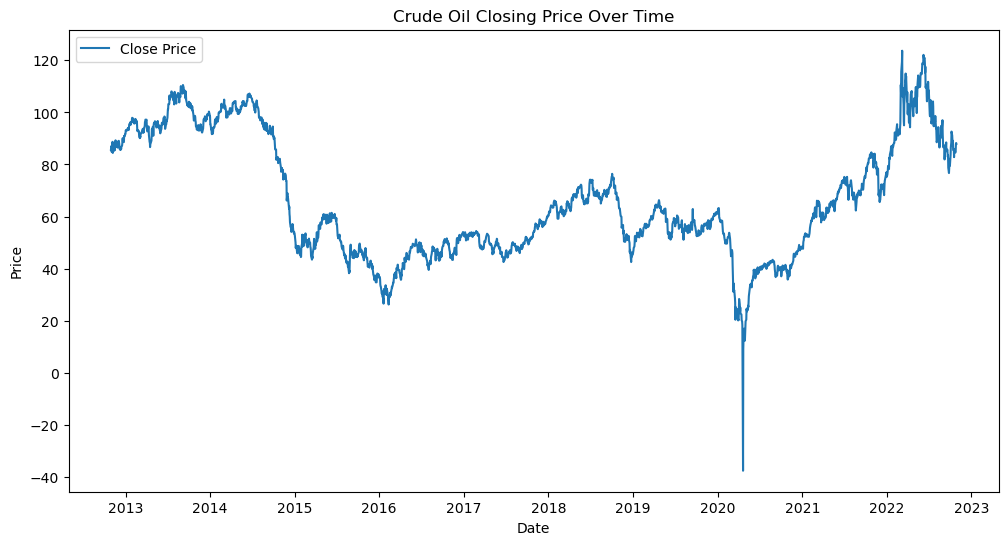

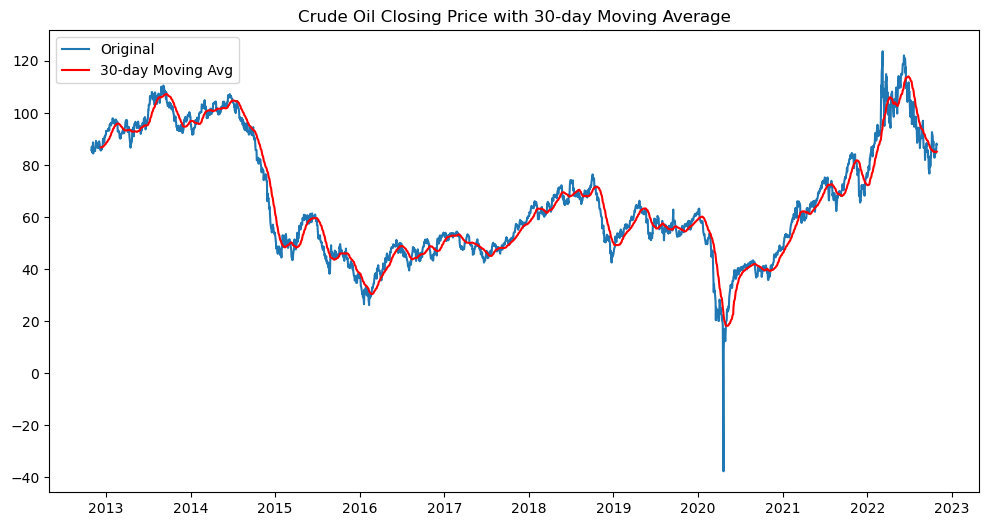

In [21]:
# 4. Target Column Analysis (Close/Last)

target = 'close/last' if 'close/last' in df.columns else 'close_last'

plt.figure(figsize=(12,6))
plt.plot(df.index, df[target], label="Close Price")
plt.title("Crude Oil Closing Price Over Time")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.show()

# Rolling Mean (30 days)
plt.figure(figsize=(12,6))
plt.plot(df.index, df[target], label="Original")
plt.plot(df[target].rolling(window=30).mean(), label="30-day Moving Avg", color='red')
plt.title("Crude Oil Closing Price with 30-day Moving Average")
plt.legend()
plt.show()

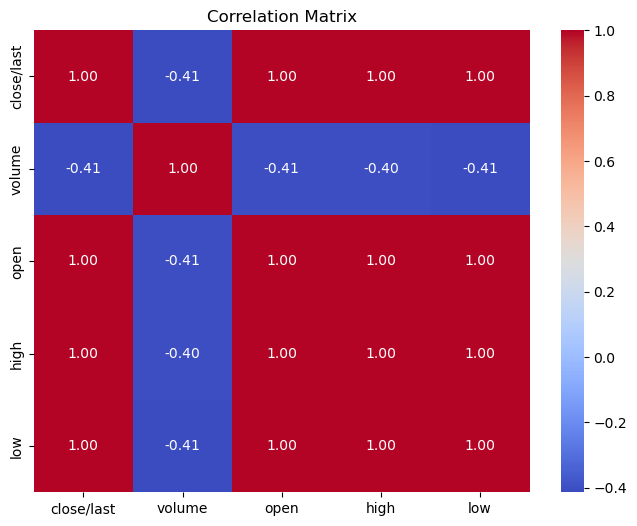

In [22]:
# 5. Correlation Analysis

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

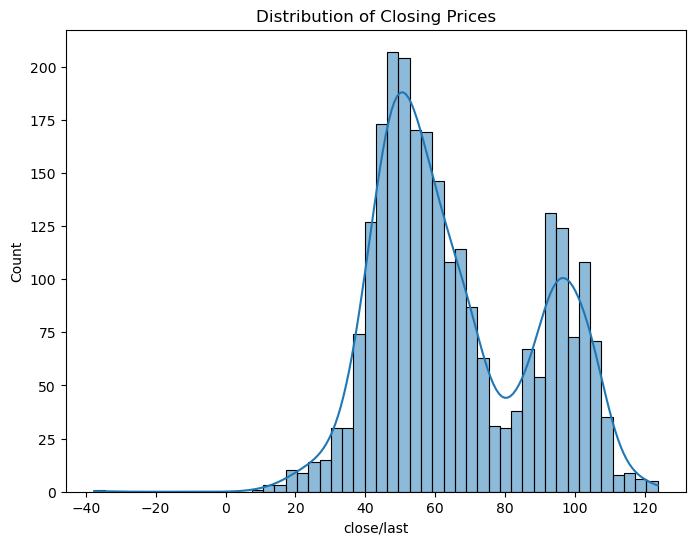

In [23]:
# 6. Distribution of Closing Prices

plt.figure(figsize=(8,6))
sns.histplot(df[target], bins=50, kde=True)
plt.title("Distribution of Closing Prices")
plt.show()

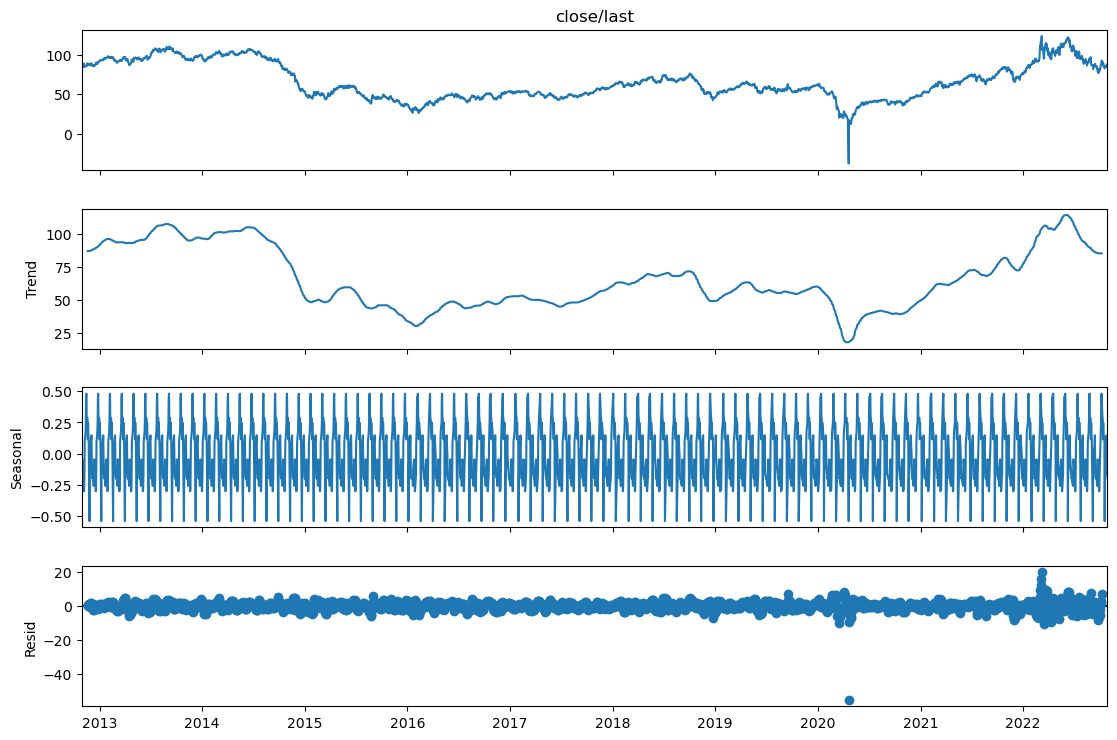

In [24]:
# 7. Time Series Decomposition

try:
    decomposition = seasonal_decompose(df[target].dropna(), model='additive', period=30)
    fig = decomposition.plot()
    fig.set_size_inches(12,8)
    plt.show()
except Exception as e:
    print("Decomposition Error:", e)

In [25]:
# 8. Feature Engineering for Forecasting

# Lag features
for lag in [1, 7, 30]:
    df[f"lag_{lag}"] = df[target].shift(lag)

# Rolling mean & std features
for window in [7, 30, 90]:
    df[f"rolling_mean_{window}"] = df[target].rolling(window=window).mean()
    df[f"rolling_std_{window}"] = df[target].rolling(window=window).std()

# Percentage change feature
df["pct_change"] = df[target].pct_change()

# Drop rows with NaN after feature creation
df = df.dropna()

print("\nFeature Engineering Completed. Dataset now has shape:", df.shape)
print("New Feature Columns:", [col for col in df.columns if col not in [target]])


Feature Engineering Completed. Dataset now has shape: (2434, 15)
New Feature Columns: ['volume', 'open', 'high', 'low', 'lag_1', 'lag_7', 'lag_30', 'rolling_mean_7', 'rolling_std_7', 'rolling_mean_30', 'rolling_std_30', 'rolling_mean_90', 'rolling_std_90', 'pct_change']


In [29]:
# ==============================
# 9. Stationarity Tests (Fixed)
# ==============================

import warnings
from statsmodels.tsa.stattools import adfuller, kpss

def adf_test(series):
    """Perform Augmented Dickey-Fuller test"""
    result = adfuller(series.dropna())
    print('\nADF Test:')
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] <= 0.05:
        print("Series is Stationary")
    else:
        print("Series is Non-Stationary")



def kpss_test(series):
    """Perform KPSS test safely"""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")  # Suppress interpolation warnings
        result = kpss(series.dropna(), regression='c', nlags="auto")
    print('\nKPSS Test:')
    print(f'KPSS Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    if result[1] > 0.05:
        print("Series is Stationary")
    else:
        print("Series is Non-Stationary")


# Run tests on target column
adf_test(df[target])
kpss_test(df[target])



ADF Test:
ADF Statistic: -2.0262
p-value: 0.2752
Series is Non-Stationary

KPSS Test:
KPSS Statistic: 1.2599
p-value: 0.0100
Series is Non-Stationary


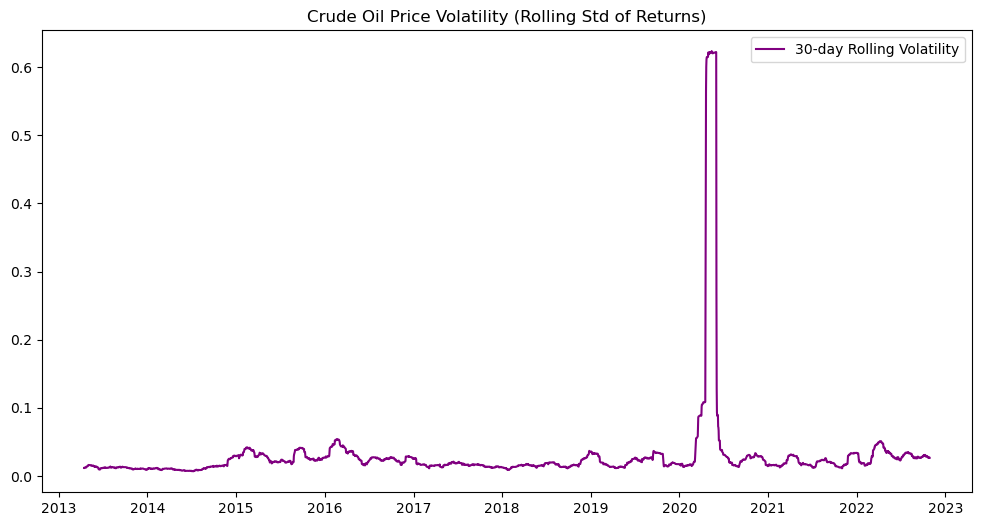

In [31]:
# 10. Volatility Analysis

plt.figure(figsize=(12,6))
plt.plot(df.index, df["pct_change"].rolling(30).std(), label="30-day Rolling Volatility", color='purple')
plt.title("Crude Oil Price Volatility (Rolling Std of Returns)")
plt.legend()
plt.show()

<Figure size 1000x400 with 0 Axes>

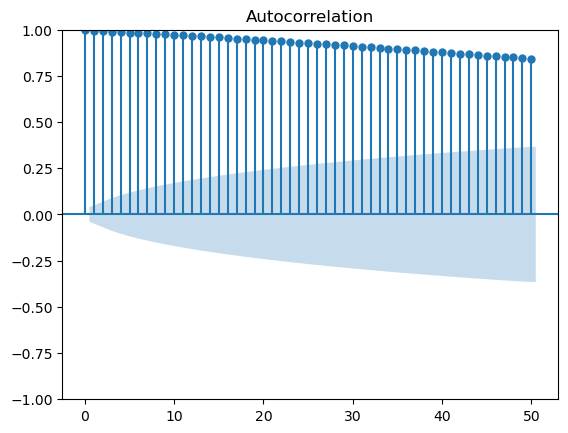

<Figure size 1000x400 with 0 Axes>

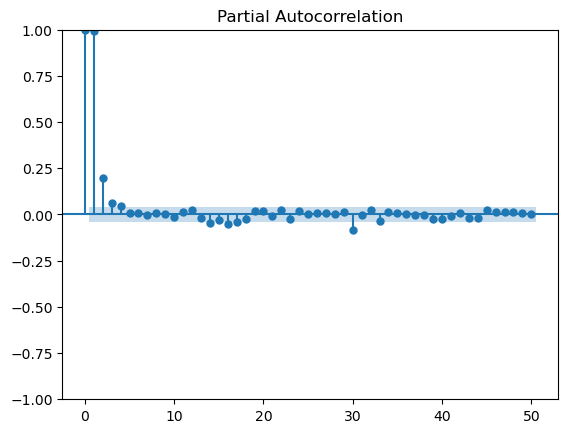

In [33]:
# Import for ACF & PACF

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf


# 11. Autocorrelation Analysis

plt.figure(figsize=(10,4))
plot_acf(df[target], lags=50)
plt.show()

plt.figure(figsize=(10,4))
plot_pacf(df[target], lags=50, method="ywm")  # safer method
plt.show()


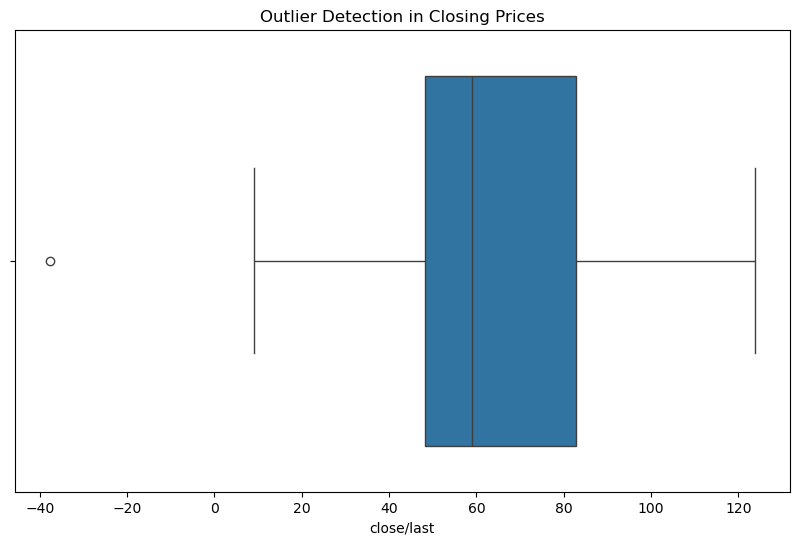

In [34]:

# 12. Outlier Detection

plt.figure(figsize=(10,6))
sns.boxplot(x=df[target])
plt.title("Outlier Detection in Closing Prices")
plt.show()

In [35]:
# 13. Final Dataset Shape
print("\nFinal dataset shape:", df.shape)
print("\nDataset Preview:")
print(df.head())


Final dataset shape: (2434, 15)

Dataset Preview:
            close/last    volume   open   high    low  lag_1  lag_7  lag_30  \
date                                                                          
2013-03-04       90.12  207844.0  90.40  90.91  89.33  90.68  92.84   95.56   
2013-03-05       90.82  175761.0  90.23  90.99  90.02  90.12  93.13   96.24   
2013-03-06       90.43  226289.0  90.83  91.17  89.55  90.82  93.11   95.23   
2013-03-07       91.56  204541.0  90.42  91.73  90.22  90.43  92.63   95.95   
2013-03-08       91.95  199349.0  91.42  92.03  90.83  91.56  92.76   95.88   

            rolling_mean_7  rolling_std_7  rolling_mean_30  rolling_std_30  \
date                                                                         
2013-03-04       92.068571       1.206226        95.350333        2.169878   
2013-03-05       91.738571       1.183208        95.169667        2.314094   
2013-03-06       91.355714       1.095854        95.009667        2.470437   
2013-